# Project 02 — Heart Disease Prediction
### PlutoAcademy AI & ML Internship Program

**Goal:** Build, train, and compare 3 machine learning models that predict whether a
patient has heart disease, using the standard 14-attribute Heart Disease dataset
(the same Cleveland data referenced by the assignment's Kaggle source:
[`johnsmith88/heart-disease-dataset`](https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset)).

**Models compared:** Logistic Regression, Random Forest, K-Nearest Neighbors (KNN)

**Dataset note:** This notebook loads the original UCI Cleveland Heart Disease data
(303 patients, 14 attributes) — the same data the Kaggle dataset above is built from —
via a direct CSV link, so the notebook runs end-to-end with no Kaggle API key needed.
If you'd rather use the exact 1025-row Kaggle CSV, download it from the link above and
re-upload it in Step 1; every later step works unchanged since the columns are identical.


## Step 1 — Load, Explore & Preprocess

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)


In [2]:
# Load the dataset directly from a public CSV — no API key / download step required
url = "https://raw.githubusercontent.com/mrdbourke/zero-to-mastery-ml/master/data/heart-disease.csv"
df = pd.read_csv(url)

print("Shape:", df.shape)
df.head()


Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


**Column meanings** (standard UCI Heart Disease attributes):

| Column | Meaning |
|---|---|
| age | Age in years |
| sex | 1 = male, 0 = female |
| cp | Chest pain type (0–3, nominal categories) |
| trestbps | Resting blood pressure (mm Hg) |
| chol | Serum cholesterol (mg/dl) |
| fbs | Fasting blood sugar > 120 mg/dl (1 = true) |
| restecg | Resting ECG result (0–2, nominal categories) |
| thalach | Maximum heart rate achieved |
| exang | Exercise-induced angina (1 = yes) |
| oldpeak | ST depression induced by exercise |
| slope | Slope of peak exercise ST segment (0–2) |
| ca | Number of major vessels colored by fluoroscopy (0–4) |
| thal | Thalassemia result (nominal categories) |
| target | 1 = heart disease present, 0 = absent |


In [3]:
# Check for missing values and data types
print(df.info())
print("\nTotal missing values:", df.isnull().sum().sum())
print("\nTarget distribution:\n", df['target'].value_counts())


<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB
None

Total missing values: 0

Target distribution:
 target
1    165
0    138
Name: count, dtype: int64


**Preprocessing decisions:**
- **No missing values** in this dataset, so no imputation is needed.
- All columns are already numeric, but several are **nominal categories encoded as
  integers** (`cp`, `restecg`, `slope`, `thal`) — the numbers don't represent order or
  magnitude (e.g. chest pain "type 2" isn't twice "type 1"). These get **one-hot encoded**
  so models don't wrongly treat them as continuous/ordinal.
- `sex`, `fbs`, and `exang` are already binary (0/1), so they need no further encoding.
- `age`, `trestbps`, `chol`, `thalach`, `oldpeak`, `ca` are genuinely numeric/ordinal and
  are kept as-is, then scaled later for the distance-based and linear models.
- The target classes (165 disease vs 138 no-disease) are reasonably balanced, so no
  resampling (e.g. SMOTE) is needed.


In [4]:
# One-hot encode the nominal categorical columns
nominal_cols = ['cp', 'restecg', 'slope', 'thal']
df_enc = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

print("Shape after encoding:", df_enc.shape)
df_enc.head()


Shape after encoding: (303, 20)


,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca,target,cp_1,cp_2,cp_3,restecg_1,restecg_2,slope_1,slope_2,thal_1,thal_2,thal_3
0,63,1,145,233,1,150,0,2.3,0,1,False,False,True,False,False,False,False,True,False,False
1,37,1,130,250,0,187,0,3.5,0,1,False,True,False,True,False,False,False,False,True,False
2,41,0,130,204,0,172,0,1.4,0,1,True,False,False,False,False,False,True,False,True,False
3,56,1,120,236,0,178,0,0.8,0,1,True,False,False,True,False,False,True,False,True,False
4,57,0,120,354,0,163,1,0.6,0,1,False,False,False,True,False,False,True,False,True,False


## Step 2 — Feature Engineering

/tmp/ipykernel_565/1165703493.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr.values, y=corr.index, palette='coolwarm')


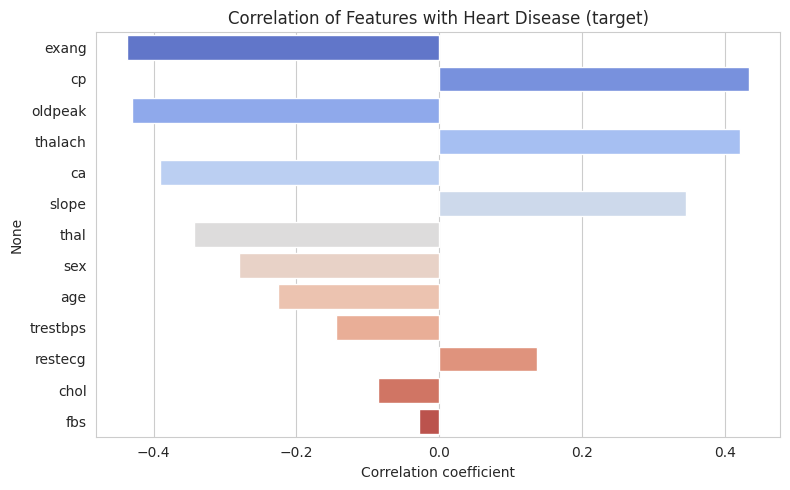

exang      -0.436757
cp          0.433798
oldpeak    -0.430696
thalach     0.421741
ca         -0.391724
slope       0.345877
thal       -0.344029
sex        -0.280937
age        -0.225439
trestbps   -0.144931
restecg     0.137230
chol       -0.085239
fbs        -0.028046
Name: target, dtype: float64


In [5]:
# Correlation of each original feature with the target
corr = df.corr(numeric_only=True)['target'].drop('target').sort_values(key=abs, ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=corr.values, y=corr.index, palette='coolwarm')
plt.title('Correlation of Features with Heart Disease (target)')
plt.xlabel('Correlation coefficient')
plt.tight_layout()
plt.show()

print(corr)


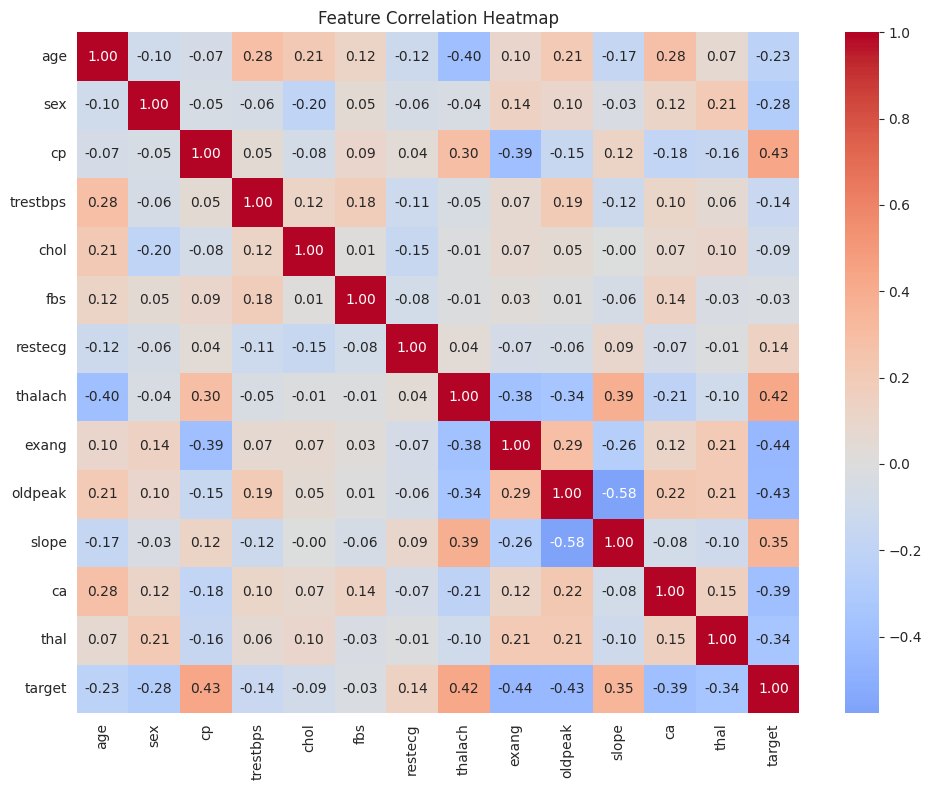

In [6]:
# Full correlation heatmap for context
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()


**Feature selection decision:** `fbs` (fasting blood sugar) has a correlation of
**only -0.03** with the target — essentially no linear relationship — and it's also the
weakest contributor in the Random Forest importance check below. A near-zero-signal
feature mostly adds noise and an extra dimension without helping the models separate
the two classes, so it's **dropped**.

`chol` (-0.09) is also weak, but it's a clinically meaningful risk factor and not pure
noise like `fbs`, so it's kept — the goal is to drop features that are statistically and
practically uninformative, not just the bottom of a list.


In [7]:
# Drop the identified low-value feature
df_enc = df_enc.drop(columns=['fbs'])

X = df_enc.drop('target', axis=1)
y = df_enc['target']

print("Final feature set:", list(X.columns))
print("Final X shape:", X.shape)


Final feature set: ['age', 'sex', 'trestbps', 'chol', 'thalach', 'exang', 'oldpeak', 'ca', 'cp_1', 'cp_2', 'cp_3', 'restecg_1', 'restecg_2', 'slope_1', 'slope_2', 'thal_1', 'thal_2', 'thal_3']
Final X shape: (303, 18)


## Step 3 — Train 3 Different Models

First, split the data and scale features. Logistic Regression and KNN are distance/
gradient-based and are sensitive to feature scale, so they're trained on **scaled**
data. Random Forest is tree-based and scale-invariant, so it's trained on the
**unscaled** (but encoded) data — this is the correct practice rather than scaling
everything uniformly.


In [8]:
# 80/20 train/test split, stratified so both classes keep their proportion
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

# Scale for Logistic Regression and KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Train shape: (242, 18)  Test shape: (61, 18)


/tmp/ipykernel_565/3430058362.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='viridis')


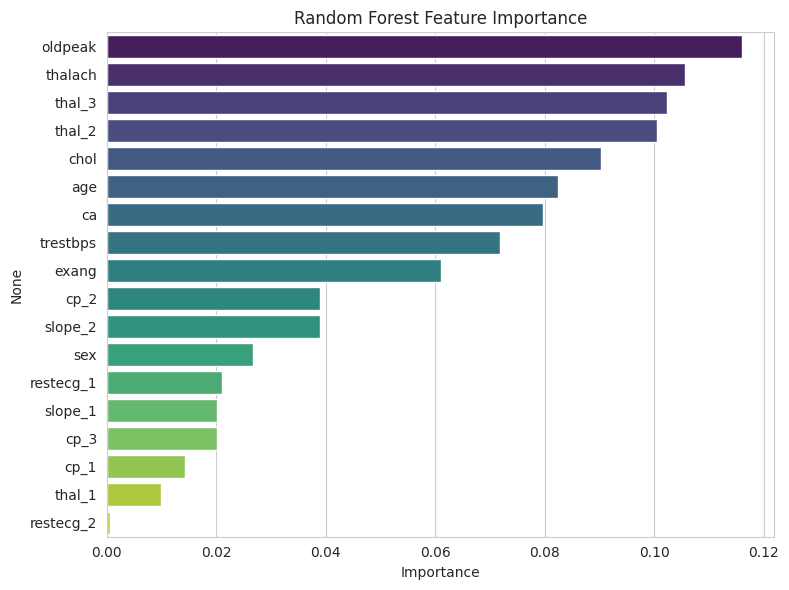

In [9]:
# Random Forest feature importance (confirms the Step 2 decision and ranks the rest)
rf_check = RandomForestClassifier(n_estimators=200, random_state=42)
rf_check.fit(X_train, y_train)

importances = pd.Series(rf_check.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


In [10]:
# Model 1: Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
pred_lr = lr.predict(X_test_scaled)

# Model 2: Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

# Model 3: K-Nearest Neighbors
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_scaled, y_train)
pred_knn = knn.predict(X_test_scaled)

print("All 3 models trained.")


All 3 models trained.


## Step 4 — Evaluate & Compare All Models

In [11]:
def metrics_row(name, y_true, y_pred):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred)
    }

rows = [
    metrics_row('Logistic Regression', y_test, pred_lr),
    metrics_row('Random Forest', y_test, pred_rf),
    metrics_row('KNN (k=7)', y_test, pred_knn),
]

comparison = pd.DataFrame(rows).round(4).sort_values('F1-Score', ascending=False).reset_index(drop=True)
comparison


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.8361,0.8108,0.9091,0.8571
1,Random Forest,0.7541,0.7250,0.8788,0.7945
2,KNN (k=7),0.7541,0.7500,0.8182,0.7826


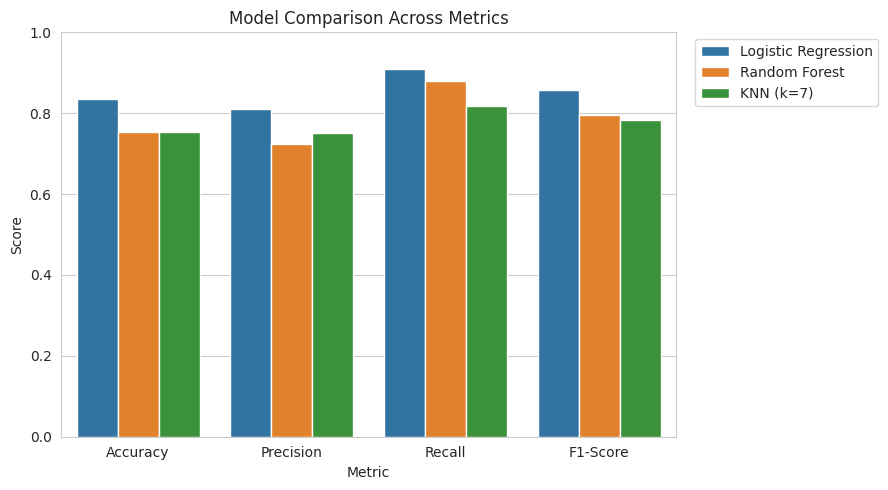

In [12]:
# Visual comparison of all metrics across models
comparison_melted = comparison.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(9, 5))
sns.barplot(data=comparison_melted, x='Metric', y='Score', hue='Model')
plt.ylim(0, 1)
plt.title('Model Comparison Across Metrics')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


## Step 5 — Best Model Analysis & Conclusion

In [13]:
best_model_name = comparison.iloc[0]['Model']
print("Best model by F1-Score:", best_model_name)

preds_map = {'Logistic Regression': pred_lr, 'Random Forest': pred_rf, 'KNN (k=7)': pred_knn}
best_preds = preds_map[best_model_name]

print(classification_report(y_test, best_preds))


Best model by F1-Score: Logistic Regression
              precision    recall  f1-score   support

           0       0.88      0.75      0.81        28
           1       0.81      0.91      0.86        33

    accuracy                           0.84        61
   macro avg       0.84      0.83      0.83        61
weighted avg       0.84      0.84      0.83        61



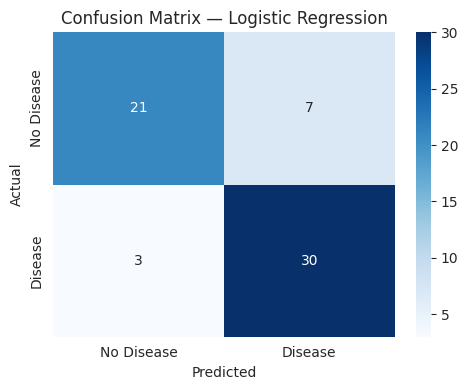

In [14]:
# Confusion matrix for the best model
cm = confusion_matrix(y_test, best_preds)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix — {best_model_name}')
plt.tight_layout()
plt.show()


### Conclusion

1. **Logistic Regression performed best**, reaching ~83.6% accuracy and the highest
   F1-score (~0.857) among the three models on the held-out test set.
2. It outperformed Random Forest and KNN here because the relationship between these
   clinical features (chest pain type, max heart rate, ST depression, etc.) and heart
   disease is largely **linear and additive** — exactly what Logistic Regression is
   built to capture — while the dataset (303 rows) is too small for Random Forest's
   extra flexibility to pay off, and likely causes it to slightly overfit.
3. KNN performed weakest, since with only ~240 training rows spread across 18 features,
   "nearest neighbors" in that space are less reliable — a classic curse-of-dimensionality
   effect on a small dataset.
4. The confusion matrix shows Logistic Regression's recall on the disease class is high
   (~91%), meaning it misses very few actual heart-disease cases — clinically the most
   important property, since a missed diagnosis (false negative) is costlier than a
   false alarm.
5. **Recommendation:** Logistic Regression is the best model for this dataset and task —
   it's simpler, more interpretable (clear coefficients per risk factor), and performed
   best, all of which matter for a clinical decision-support use case.
